In [ ]:
# importing necessary libraries

import cv2
import numpy as np
import urllib.request
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam
from keras.regularizers import l2
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

Data Preparation and Exploration

In [ ]:
# loading the dataset

(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, y_train.shape

((40000, 32, 32, 3), (40000, 1))

In [ ]:
X_valid.shape, y_valid.shape

((10000, 32, 32, 3), (10000, 1))

In [ ]:
X_test.shape, y_test.shape

((10000, 32, 32, 3), (10000, 1))

In [ ]:
set(y_train.flatten())

{np.uint8(0),
 np.uint8(1),
 np.uint8(2),
 np.uint8(3),
 np.uint8(4),
 np.uint8(5),
 np.uint8(6),
 np.uint8(7),
 np.uint8(8),
 np.uint8(9)}

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

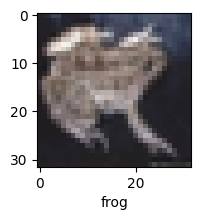

In [ ]:
plt.figure(figsize=(2,2))
plt.xlabel(class_names[y_train[0][0]])
plt.imshow(X_train[0])

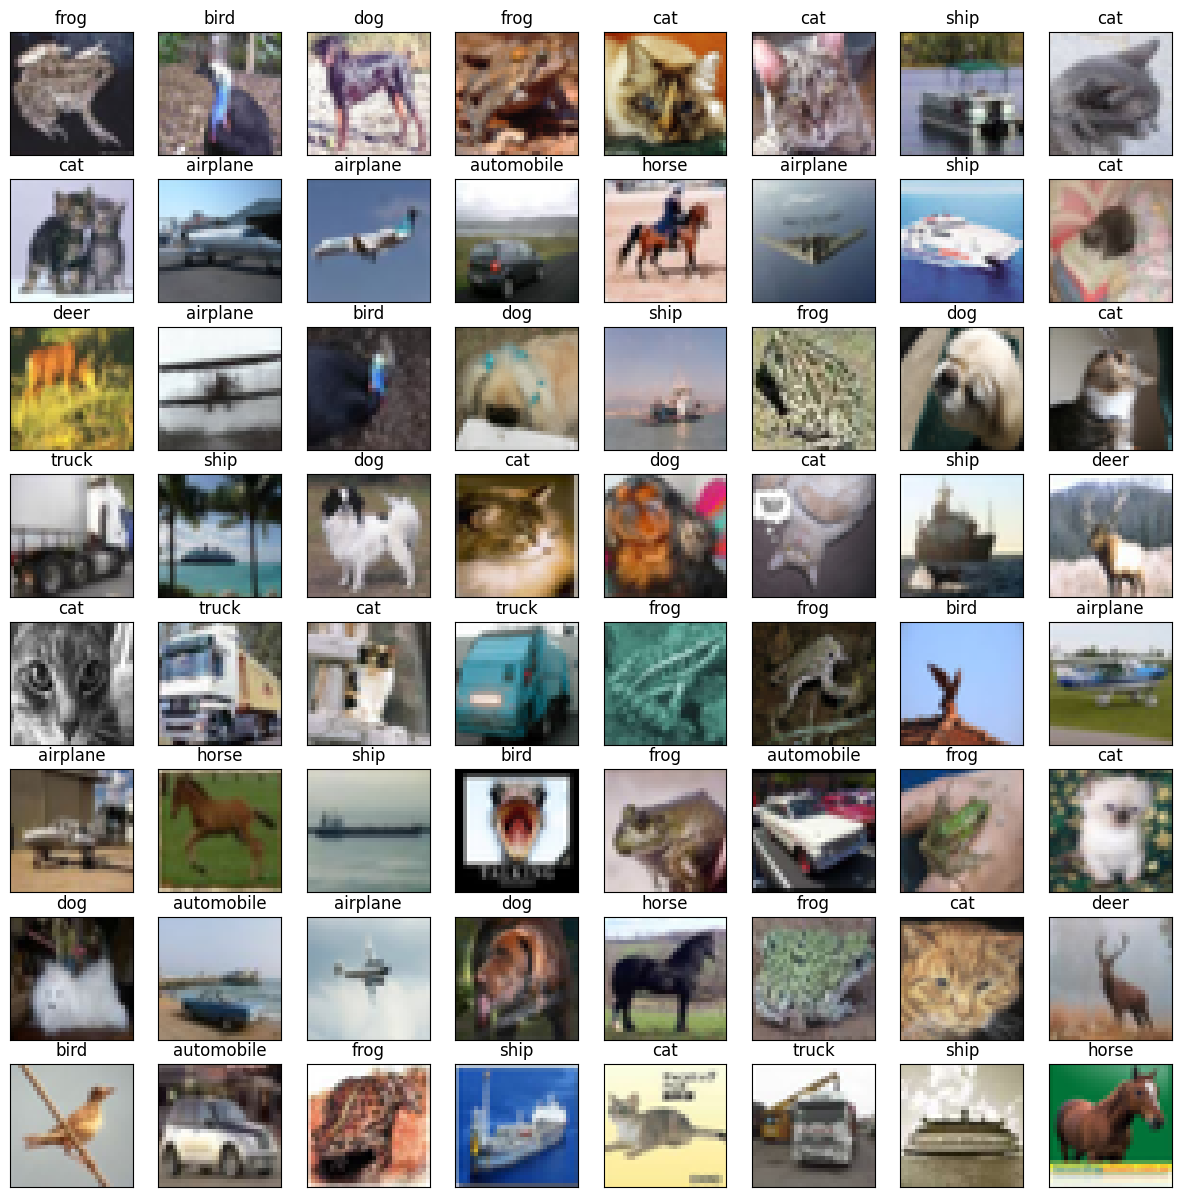

In [ ]:
plt.figure(figsize = (15, 15))

for i in range(64):
    plt.subplot(8, 8, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])

Data Preprocessing

1. Normalization of images

2. One hot encoding of Labels

3. Data Augmentation

#### Normalization

In [ ]:
X_train.dtype

dtype('uint8')

In [ ]:
# Converting the pixel values into float32

X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
X_valid = X_valid.astype("float32")

In [ ]:
# Calculate the mean and std of training images
mean = np.mean(X_train)
std = np.std(X_train)

# Normalize the data
X_train = (X_train - mean) / (std + .000000001)
X_test = (X_test - mean) / (std + .000000001)
X_valid = (X_valid - mean) / (std + .000000001)

#### One Hot Encoding of Labels

In [ ]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)
y_valid = to_categorical(y_valid, 10)

#### Data Augmentation

In [ ]:
data_generator = ImageDataGenerator(
    rotation_range = 15, # Rotate image by up to 15 degree
    width_shift_range = 0.12, # Shift images horizontally upto 12%
    height_shift_range = 0.12, # Shift images
    horizontal_flip = True,
    zoom_range = 0.1,
    brightness_range = [0.9, 1.1],
    shear_range = 10, # Shear intesity (shear angle in anti clockwise direction)
    channel_shift_range = 0.1
)

Model

In [ ]:
model = Sequential()

weight_decay = 0.0001 # Weight decay for L2 regularization

# Add First and Second Conv layers
model.add(Conv2D(filters = 32, kernel_size = (3, 3), padding = "same", activation = "relu", kernel_regularizer = l2(weight_decay), input_shape = X_train.shape[1:]))
model.add(BatchNormalization())

model.add(Conv2D(filters = 32, kernel_size = (3, 3), padding = "same", activation = "relu", kernel_regularizer = l2(weight_decay), input_shape = X_train.shape[1:]))
model.add(BatchNormalization())

# Add First max pooling layer with pool size of (2, 2)
model.add(MaxPooling2D(pool_size=(2, 2)))
# Add dropout layer with 0.2 dropout rate
model.add(Dropout(rate=0.2))

# Add Third and Fourth Conv layer
model.add(Conv2D(filters = 64, kernel_size = (3, 3), padding = "same", activation = "relu", kernel_regularizer = l2(weight_decay), ))
model.add(BatchNormalization())

model.add(Conv2D(filters = 64, kernel_size = (3, 3), padding = "same", activation = "relu", kernel_regularizer = l2(weight_decay), ))
model.add(BatchNormalization())

# Add Second max pooling layer with pool size of (2, 2)
model.add(MaxPooling2D(pool_size=(2, 2)))
# Add dropout layer with 0.3 dropout rate
model.add(Dropout(rate=0.3))

# Add Fifth and Sixth Conv layer
model.add(Conv2D(filters = 128, kernel_size = (3, 3), padding = "same", activation = "relu", kernel_regularizer = l2(weight_decay), ))
model.add(BatchNormalization())

model.add(Conv2D(filters = 128, kernel_size = (3, 3), padding = "same", activation = "relu", kernel_regularizer = l2(weight_decay), ))
model.add(BatchNormalization())

# Add Third max pooling layer with pool size of (2, 2)
model.add(MaxPooling2D(pool_size=(2, 2)))
# Add dropout layer with 0.4 dropout rate
model.add(Dropout(rate=0.4))

# Add Seventh and Eighth Conv layer
model.add(Conv2D(filters = 256, kernel_size = (3, 3), padding = "same", activation = "relu", kernel_regularizer = l2(weight_decay), ))
model.add(BatchNormalization())

model.add(Conv2D(filters = 256, kernel_size = (3, 3), padding = "same", activation = "relu", kernel_regularizer = l2(weight_decay), ))
model.add(BatchNormalization())

# Add Fourth max pooling layer with pool size of (2, 2)
model.add(MaxPooling2D(pool_size=(2, 2)))
# Add dropout layer with 0.5 dropout rate
model.add(Dropout(rate=0.5))


# Flatten the tensor output from the previous layer
model.add(Flatten())

# Add a fully connected layer with softmax activation function
model.add(Dense(10, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,186,346 (4.53 MB)

 Trainable params: 1,184,426 (4.52 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
batch_size = 64

epochs = 300

optimizer = Adam(learning_rate= 0.0005)

model.compile(optimizer= optimizer, loss= "categorical_crossentropy", metrics=['accuracy'])

reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, min_lr=0.0001)

early_stopping = EarlyStopping(monitor="val_loss", patience=40, restore_best_weights=True, verbose=1)

model.fit(data_generator.flow(X_train, y_train, batch_size = batch_size),
                              epochs = epochs,
                              validation_data = (X_valid, y_valid),
                              callbacks = [reduce_lr, early_stopping],
                              verbose=2)

Epoch 1/300
625/625 - 64s - 102ms/step - accuracy: 0.3222 - loss: 2.4292 - val_accuracy: 0.4354 - val_loss: 1.7886 - learning_rate: 5.0000e-04
Epoch 2/300
625/625 - 42s - 68ms/step - accuracy: 0.4478 - loss: 1.7684 - val_accuracy: 0.4907 - val_loss: 1.5929 - learning_rate: 5.0000e-04
Epoch 3/300
625/625 - 42s - 67ms/step - accuracy: 0.5128 - loss: 1.5514 - val_accuracy: 0.5332 - val_loss: 1.3956 - learning_rate: 5.0000e-04
Epoch 4/300
625/625 - 43s - 68ms/step - accuracy: 0.5596 - loss: 1.3905 - val_accuracy: 0.5349 - val_loss: 1.5134 - learning_rate: 5.0000e-04
Epoch 5/300
625/625 - 42s - 68ms/step - accuracy: 0.5958 - loss: 1.2844 - val_accuracy: 0.6523 - val_loss: 1.1270 - learning_rate: 5.0000e-04
Epoch 6/300
625/625 - 44s - 70ms/step - accuracy: 0.6263 - loss: 1.1749 - val_accuracy: 0.6844 - val_loss: 1.0031 - learning_rate: 5.0000e-04
Epoch 7/300
625/625 - 43s - 69ms/step - accuracy: 0.6607 - loss: 1.0893 - val_accuracy: 0.7090 - val_loss: 0.9584 - learning_rate: 5.0000e-04
Epoch

Visualizing the Learning Curves

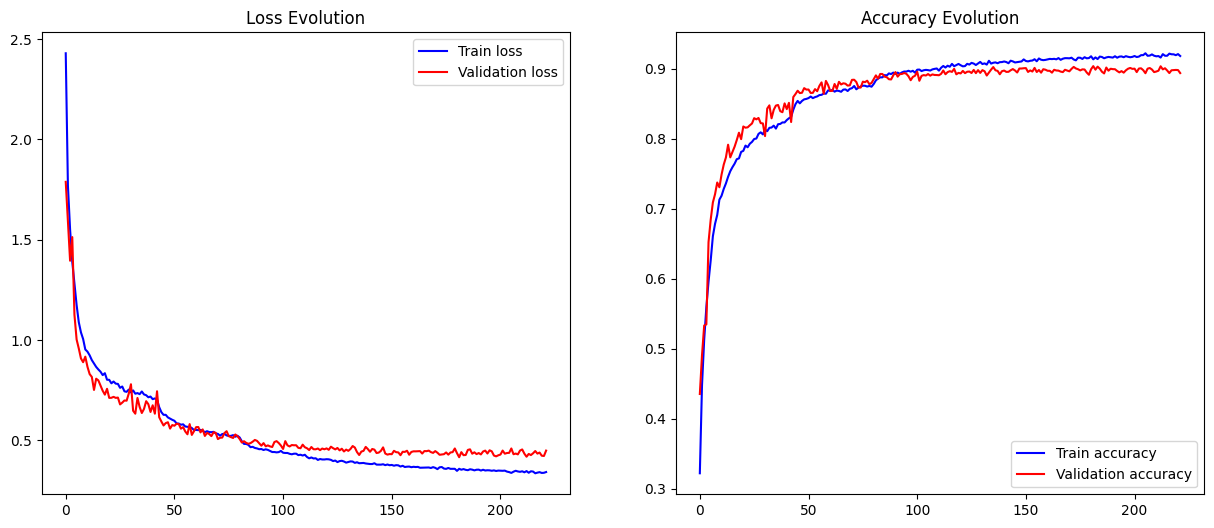

In [65]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(model.history.history['loss'], label = "Train loss", color = "blue")
plt.plot(model.history.history['val_loss'], label = "Validation loss", color = "red")
plt.legend()
plt.title("Loss Evolution")

plt.subplot(1, 2, 2)
plt.plot(model.history.history['accuracy'], label = "Train accuracy", color = "blue")
plt.plot(model.history.history['val_accuracy'], label = "Validation accuracy", color = "red")
plt.legend()
plt.title("Accuracy Evolution")

plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)

print(f"Test Accuracy: {test_acc} \nTest Loss: {test_loss}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8977 - loss: 0.4360
Test Accuracy: 0.8977000117301941 
Test Loss: 0.43603697419166565


#### Performance on an out of Dataset Image

In [51]:
url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRUv7pxNTNCXV6qvtCYOYxpIMEp5hcQPro_AA&s"

repo = urllib.request.urlopen(url)

image = np.asarray(bytearray(repo.read()), dtype = "uint8")
image = cv2.imdecode(image, cv2.IMREAD_UNCHANGED)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert the image from bgr to rgb


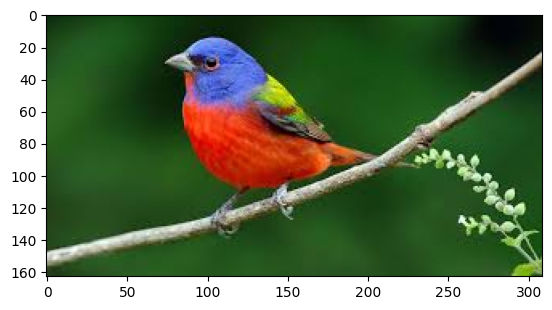

In [52]:
plt.imshow(image)
plt.show()

In [53]:
image.shape

(163, 309, 3)

In [54]:
image = cv2.resize(image, (32, 32))

# normalize the image
image = (image - mean) / (std + 0.0000001)

# Add extra dimension because the model expects a batch of images
image = image.reshape((1, 32, 32, 3))

In [55]:
predict = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [56]:
predict

array([[1.0148973e-02, 1.6175558e-05, 9.8929721e-01, 2.2648939e-05,
        1.3603510e-04, 4.6164281e-05, 3.0881690e-04, 3.3868159e-06,
        1.6191701e-05, 4.5368611e-06]], dtype=float32)

In [57]:
predict.argmax()

np.int64(2)

In [58]:
class_names[predict.argmax()]

'bird'

In [63]:
# =========================================
# 2. Save Keras model (full model)
# =========================================
model.save(os.path.join(save_dir, 'cnn_cifar10_model.h5'))
# Optional: TensorFlow SavedModel format
model.save(os.path.join(save_dir, 'cnn_cifar10_savedmodel'))

print("Model saved!")

Saved artifact at './cnn_cifar10_saved/cnn_cifar10_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  137859029728528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137859029728144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137858720335440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137858720336016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137858720334864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137858720334480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137859029728336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137858720334672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137858720338128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137858720338512: TensorSpec(shape=(), dtype=tf.resource, na

In [66]:
# =========================================
# Save everything for your CIFAR-10 CNN
# =========================================

import os
import pickle
from keras.models import load_model

# 1️⃣ Create save directory
save_dir = './cnn_cifar10_saved'
os.makedirs(save_dir, exist_ok=True)

# 2️⃣ Save the model in modern Keras format (includes architecture, weights, optimizer)
model_path = os.path.join(save_dir, 'cnn_cifar10_model.keras')
model.save(model_path)
print(f"✅ Model saved at: {model_path}")

# 3️⃣ Save training history (loss and accuracy)
history_dict = {
    'loss': history.history['loss'],
    'val_loss': history.history.get('val_loss', []),
    'accuracy': history.history.get('accuracy', []),
    'val_accuracy': history.history.get('val_accuracy', [])
}
history_path = os.path.join(save_dir, 'history.pkl')
with open(history_path, 'wb') as f:
    pickle.dump(history_dict, f)
print(f"✅ Training history saved at: {history_path}")

# 4️⃣ Save preprocessing info (mean, std, any custom transforms)
preprocessing_info = {
    'mean': [0.4914, 0.4822, 0.4465],  # CIFAR-10 mean
    'std': [0.2023, 0.1994, 0.2010],   # CIFAR-10 std
}
preprocessing_path = os.path.join(save_dir, 'preprocessing.pkl')
with open(preprocessing_path, 'wb') as f:
    pickle.dump(preprocessing_info, f)
print(f"✅ Preprocessing info saved at: {preprocessing_path}")

# 5️⃣ Save Python environment requirements for reproducibility
!pip freeze > {os.path.join(save_dir, 'requirements.txt')}
print(f"✅ Python environment saved at: {os.path.join(save_dir, 'requirements.txt')}")

# 6️⃣ Optional: List all files
print("\n📂 All files saved in directory:")
print(os.listdir(save_dir))

✅ Model saved at: ./cnn_cifar10_saved/cnn_cifar10_model.keras


NameError: name 'history' is not defined

In [67]:
# =========================================
# Save trained model and preprocessing for Streamlit
# =========================================
import os
import pickle

# 1️⃣ Create local save directory
save_dir = './cnn_cifar10_saved'
os.makedirs(save_dir, exist_ok=True)

# 2️⃣ Save the trained model in modern Keras format
model_path = os.path.join(save_dir, 'cnn_cifar10_model.keras')
model.save(model_path)
print(f"✅ Model saved at: {model_path}")

# 3️⃣ Save existing preprocessing variables (mean & std)
preprocessing_info = {
    'mean': mean,  # use your existing mean variable
    'std': std     # use your existing std variable
}
preprocessing_path = os.path.join(save_dir, 'preprocessing.pkl')
with open(preprocessing_path, 'wb') as f:
    pickle.dump(preprocessing_info, f)
print(f"✅ Preprocessing info saved at: {preprocessing_path}")

# 4️⃣ Optional: list all files to verify
print("\n📂 Files saved in directory:")
print(os.listdir(save_dir))

✅ Model saved at: ./cnn_cifar10_saved/cnn_cifar10_model.keras
✅ Preprocessing info saved at: ./cnn_cifar10_saved/preprocessing.pkl

📂 Files saved in directory:
['cnn_cifar10_model.keras', 'cnn_cifar10_model.h5', 'cnn_cifar10_savedmodel', 'preprocessing.pkl']
